# Module E: Document-Level AI-Content Quantification

**Goal:** given a finished document, estimate **what % of it still comes from the LLM draft** (the rest is human-written).

**How:**
1. Build an answer key: for every document, the real % that survived from the LLM draft (word-by-word comparison).
2. Use Module C's sentence classifier to score every sentence, then combine the sentence scores into one document-level %.
3. The raw % is biased (the classifier flags too much human text as AI), so we **calibrate** it: fit a small correction on the *validation* participants, then measure the error on the *test* participants the model never saw.

## 1. Setup

In [1]:
import os, re, json, glob, subprocess, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from difflib import SequenceMatcher
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score
import nltk
from nltk.tokenize import sent_tokenize

warnings.filterwarnings("ignore")
nltk.download("punkt_tab", quiet=True)

OUT_DIR = "task_E_results"
os.makedirs(OUT_DIR, exist_ok=True)

# the project repo gives us the 81 logs, the split lists and (through Git LFS) the model.
# GIT_LFS_SKIP_SMUDGE skips the 500 MB model download at clone time. We only fetch it if we need it.

if os.path.isdir(os.path.join("task_C", "roberta_ai_human_model")):
    REPO_DIR = "."
elif os.path.isdir(os.path.join("MLProject", "task_C")):
    REPO_DIR = "MLProject"
else:
    REPO_DIR = "MLProject"
    subprocess.run(
        ["git", "clone", "https://github.com/harshitaagrawalIT123/MLProject", REPO_DIR],
        env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
        check=True
    )

# If your copy of the model is on Google Drive, uncomment these two lines first:
# from google.colab import drive
# drive.mount("/content/drive")

# Where is the model? The first folder below that has a full-size model.safetensors is used.
# Put your own path at the top of the list if your copy is somewhere else.
MODEL_CANDIDATES = [
    # "D:/IIT BH in D/ML/Project/Part E/roberta_ai_human_model",
    "/content/drive/MyDrive/task_C/roberta_ai_human_model",     # a copy on Google Drive
    "MLProject/task_C/roberta_ai_human_model",                   # the copy inside the project repo
    "task_C/roberta_ai_human_model",

]

def has_model(folder):
    f = os.path.join(folder, "model.safetensors")
    return os.path.exists(f) and os.path.getsize(f) > 400e6

MODEL_DIR = next((p for p in MODEL_CANDIDATES if has_model(p)), None)

if MODEL_DIR is None:
    print("No full model found locally. Downloading it from the repo with Git LFS (about 500 MB)...")
    subprocess.run(["git", "lfs", "install"])
    subprocess.run(["git", "lfs", "pull"], cwd="MLProject")
    MODEL_DIR = "MLProject/task_C/roberta_ai_human_model"

assert has_model(MODEL_DIR), "No complete model.safetensors (about 499 MB) found. Add your copy of the model folder to MODEL_CANDIDATES, or fix Git LFS (cd MLProject && git lfs pull)."
print("using model folder:", MODEL_DIR)
print("files:", os.listdir(MODEL_DIR))
print("model.safetensors size (MB):", round(os.path.getsize(os.path.join(MODEL_DIR, "model.safetensors")) / 1e6), "(expected about 499)")

using model folder: D:/IIT BH in D/ML/Project/Part E/roberta_ai_human_model
files: ['config.json', 'evaluation.json', 'model.safetensors', 'tokenizer.json', 'tokenizer_config.json', 'training_args.bin']
model.safetensors size (MB): 499 (expected about 499)


## 2. Load the documents
Same loading as in A1. `type` = **treatment** (person post-edited an LLM draft) or **control** (person wrote alone and never saw the draft).

In [4]:
rows = []
for file in glob.glob("MLProject/logs/*.json"):
    data = json.load(open(file, encoding="utf-8"))
    pid = data["user_info"]["id"]
    for task in data["responses"].values():
        if "scenario" not in task:
            continue
        rows.append({
            "pid": pid,
            "scenario": task["scenario"],
            "type": "treatment" if task["model_generation_shown"] == 1 else "control",
            "draft": task["model_generation"],
            "final": task["final_version"],
        })

df = pd.DataFrame(rows)
print(df["type"].value_counts())
print("participants:", df["pid"].nunique())

type
treatment    324
control      162
Name: count, dtype: int64
participants: 81


## 3. The answer key: how much of each document really came from the draft
A word in the final text counts as **AI** if it sits inside a run of **3 or more words in a row** that also appears in the LLM draft. Everything else is human.

Control texts get a true value of **0**, because those people never saw the draft.

In [5]:
def get_words(text):
    text = text.lower().replace("’", "'")
    return re.findall(r"[a-z0-9']+", text)

def ai_word_mask(draft, final, min_run=3):
    d = get_words(draft)
    f = get_words(final)
    mask = [0] * len(f)                          # 1 = word came from the draft
    matcher = SequenceMatcher(None, d, f, autojunk=False)
    for block in matcher.get_matching_blocks():
        if block.size >= min_run:
            for i in range(block.b, block.b + block.size):
                mask[i] = 1
    return mask

df["mask"] = [ai_word_mask(d, f) for d, f in zip(df["draft"], df["final"])]
df["true_ai_pct"] = df["mask"].apply(lambda m: 100 * np.mean(m))
df["truth"] = np.where(df["type"] == "treatment", df["true_ai_pct"], 0.0)

print(df.groupby("type")["truth"].describe().round(1))

           count  mean   std  min   25%   50%   75%    max
type                                                      
control    162.0   0.0   0.0  0.0   0.0   0.0   0.0    0.0
treatment  324.0  85.8  19.9  0.0  84.3  91.6  98.6  100.0


## 4. Which participants are fit / validation / test
Module C's classifier was **trained on 45 participants**, used **12 for validation**, and **24 are held out for test** (the split from A3). We repeat his split with the same seed to find the 12 validation participants.

**Rule: we never score the 45 training participants**, because the model has already seen their texts and would look better than it really is.

In [6]:
def get_ids(path):
    ids = []
    for line in open(path, encoding="utf-8"):
        line = line.strip()
        if line:
            ids.append(re.split(r"[\\/]", line)[-1].replace(".json", ""))
    return ids

train_ids = get_ids("MLProject/task_A3/train_files.txt")
test_ids  = get_ids("MLProject/task_A3/test_files.txt")

groups = np.array(train_ids)
splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
fit_idx, val_idx = next(splitter.split(groups, groups=groups))
val_ids = list(groups[val_idx])

df["split"] = "fit"
df.loc[df["pid"].isin(val_ids), "split"] = "val"
df.loc[df["pid"].isin(test_ids), "split"] = "test"
print(df.groupby(["split", "type"]).size().unstack())

type   control  treatment
split                    
fit         90        180
test        48         96
val         24         48


## 5. Load Module C's classifier and score sentences
Same settings as his notebook: NLTK sentence splitting, 128 tokens max, class 1 = AI.

In [7]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

device = "cuda" if torch.cuda.is_available() else "cpu"
try:
    tok = AutoTokenizer.from_pretrained(MODEL_DIR)
except Exception:
    tok = AutoTokenizer.from_pretrained("roberta-base")      # the same tokenizer his model was built on
clf = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR).to(device).eval()

def score_sentences(text):
    sents = [s.strip() for s in sent_tokenize(text) if s.strip()]
    probs = []
    for i in range(0, len(sents), 16):
        batch = sents[i:i + 16]
        enc = tok(batch, truncation=True, max_length=128, padding=True, return_tensors="pt").to(device)
        with torch.no_grad():
            logits = clf(**enc).logits
        probs += torch.softmax(logits, dim=1)[:, 1].tolist()      # column 1 = AI
    return list(zip(sents, probs))

print(score_sentences("Hello Paul! Thank you so much for standing with me."))

[('Hello Paul!', 0.6815765500068665), ('Thank you so much for standing with me.', 0.7572293281555176)]


## 6. Score every validation and test document
Each document gets three simple scores, all in %:
- `pred_frac_ai`: share of sentences flagged AI (probability ≥ 0.8, his cutoff)
- `pred_wordweighted_ai`: the same, but weighted by sentence length (so "Hello!" counts less than a long sentence). **This is our main score**, chosen in advance because the answer key is also word-based.
- `pred_mean_prob`: average AI probability

In [8]:
CUTOFF = 0.8

def doc_scores(pairs):
    probs = np.array([p for s, p in pairs])
    lens  = np.array([len(s.split()) for s, p in pairs])
    flagged = probs >= CUTOFF
    return {
        "pred_frac_ai": 100 * flagged.mean(),
        "pred_wordweighted_ai": 100 * (lens * flagged).sum() / lens.sum(),
        "pred_mean_prob": 100 * probs.mean(),
    }

scored = df[df["split"].isin(["val", "test"])].copy().reset_index(drop=True)
scored["pairs"] = scored["final"].apply(score_sentences)        # takes a few minutes
scored = pd.concat([scored, scored["pairs"].apply(doc_scores).apply(pd.Series)], axis=1)
print(len(scored), "documents scored")

216 documents scored


## 7. Raw results (before calibration)
Look at the **control** rows. Those documents are 100% human, so any predicted value above 0 is the classifier's false-alarm bias.

In [9]:
PRIMARY = "pred_wordweighted_ai"

print(scored.groupby(["split", "type"])[["truth", "pred_frac_ai", "pred_wordweighted_ai", "pred_mean_prob"]].mean().round(1))

t = scored[scored["type"] == "treatment"]
print("\nCorrelation with the truth, post-edited docs only:")
print(t[["truth", "pred_frac_ai", "pred_wordweighted_ai", "pred_mean_prob"]].corr().round(2)["truth"])

                 truth  pred_frac_ai  pred_wordweighted_ai  pred_mean_prob
split type                                                                
test  control      0.0          21.0                  19.2            26.4
      treatment   86.5          86.2                  87.1            86.9
val   control      0.0          17.4                  15.1            25.1
      treatment   90.9          90.6                  90.9            90.3

Correlation with the truth, post-edited docs only:
truth                   1.00
pred_frac_ai            0.78
pred_wordweighted_ai    0.77
pred_mean_prob          0.83
Name: truth, dtype: float64


## 8. Calibration
Fit a straight line `true % = a + b * predicted %` on the **validation** participants (their 48 post-edited and 24 control documents), then apply it to the **test** participants and measure the error there.

We compare against a "dumb" guess: always say the average true value from the validation set. Because most documents are mostly AI, this dumb guess is not as bad as it sounds.

In [10]:
val  = scored[scored["split"] == "val"].copy()
test = scored[scored["split"] == "test"].copy()

cal = LinearRegression().fit(val[[PRIMARY]], val["truth"])
print(f"calibration: true% = {cal.intercept_:.1f} + {cal.coef_[0]:.2f} * predicted%")

test["calibrated"] = np.clip(cal.predict(test[[PRIMARY]]), 0, 100)
test["dumb"] = val["truth"].mean()

def metrics(true, pred):
    r = np.corrcoef(true, pred)[0, 1] if np.std(pred) > 0 else np.nan
    return {"MAE": np.mean(np.abs(true - pred)),
            "RMSE": np.sqrt(np.mean((true - pred) ** 2)),
            "r": r}

table = []
for name, d in [("all test docs", test), ("post-edited only", test[test["type"] == "treatment"]),
                ("control only", test[test["type"] == "control"])]:
    for label, col in [("raw", PRIMARY), ("calibrated", "calibrated"), ("dumb (always the mean)", "dumb")]:
        m = metrics(d["truth"].values, d[col].values)
        table.append({"documents": name, "prediction": label, **m})
table = pd.DataFrame(table)
print(table.round(2).to_string(index=False))
table.round(3).to_csv(f"{OUT_DIR}/results_table.csv", index=False)

calibration: true% = -10.7 + 1.09 * predicted%
       documents             prediction   MAE  RMSE     r
   all test docs                    raw 11.81 20.44  0.90
   all test docs             calibrated 10.75 18.97  0.91
   all test docs dumb (always the mean) 42.06 44.80   NaN
post-edited only                    raw  8.12 13.70  0.80
post-edited only             calibrated  9.18 14.32  0.80
post-edited only dumb (always the mean) 32.79 34.26 -0.00
    control only                    raw 19.19 29.63   NaN
    control only             calibrated 13.88 25.87   NaN
    control only dumb (always the mean) 60.60 60.60   NaN


### How sure are we?
With only 24 test participants, one number can be misleading, so we resample participants 1000 times to get a 95% interval. The key question: **does calibrated beat the dumb guess on post-edited documents?**

In [11]:
def boot_ci(d, col, n=1000):
    by_pid = [g[col].values for _, g in d.groupby("pid")]
    rng = np.random.default_rng(0)
    means = []
    for _ in range(n):
        pick = rng.integers(0, len(by_pid), len(by_pid))
        means.append(np.concatenate([by_pid[i] for i in pick]).mean())
    return np.percentile(means, [2.5, 97.5])

pe = test[test["type"] == "treatment"].copy()
pe["err_cal"]  = (pe["truth"] - pe["calibrated"]).abs()
pe["err_dumb"] = (pe["truth"] - pe["dumb"]).abs()
pe["err_raw"]  = (pe["truth"] - pe[PRIMARY]).abs()
pe["gain"]     = pe["err_dumb"] - pe["err_cal"]          # positive = calibrated is better

for col, label in [("err_raw", "raw"), ("err_cal", "calibrated"), ("err_dumb", "dumb")]:
    lo, hi = boot_ci(pe, col)
    print(f"MAE {label:11s}: {pe[col].mean():5.1f}   95% CI [{lo:.1f}, {hi:.1f}]")

lo, hi = boot_ci(pe, "gain")
print(f"\ncalibrated beats the dumb guess by {pe['gain'].mean():.1f} points   95% CI [{lo:.1f}, {hi:.1f}]")
print("-> better than guessing the mean (95% interval is above 0)" if lo > 0 else "-> NOT clearly better than guessing the mean (95% interval includes 0)")

MAE raw        :   8.1   95% CI [5.8, 10.8]
MAE calibrated :   9.2   95% CI [7.0, 11.6]
MAE dumb       :  32.8   95% CI [29.8, 35.4]

calibrated beats the dumb guess by 23.6 points   95% CI [19.0, 27.8]
-> better than guessing the mean (95% interval is above 0)


## 9. Plots

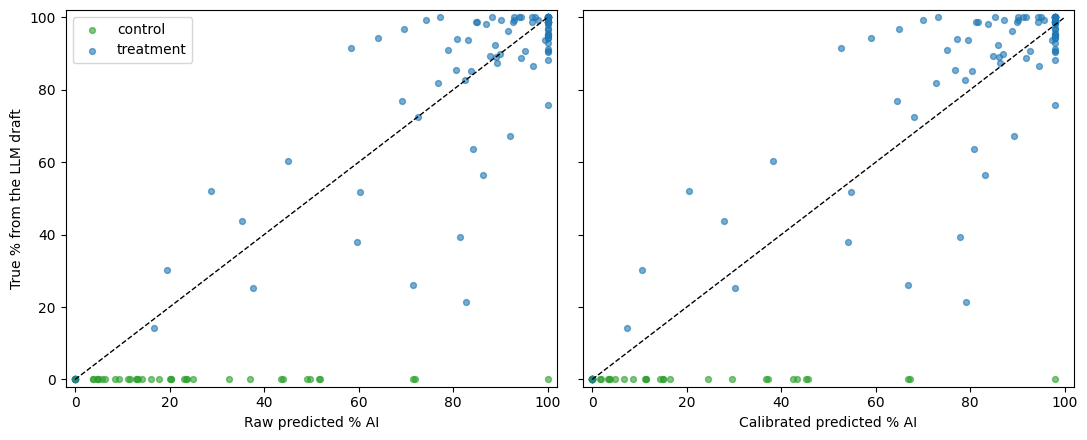

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for a, col, title in [(ax[0], PRIMARY, "Raw predicted % AI"), (ax[1], "calibrated", "Calibrated predicted % AI")]:
    for typ, color in [("control", "tab:green"), ("treatment", "tab:blue")]:
        d = test[test["type"] == typ]
        a.scatter(d[col], d["truth"], s=18, alpha=0.6, color=color, label=typ)
    a.plot([0, 100], [0, 100], "k--", lw=1)
    a.set_xlabel(title); a.set_xlim(-2, 102); a.set_ylim(-2, 102)
ax[0].set_ylabel("True % from the LLM draft")
ax[0].legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig_calibration.png", dpi=150)
plt.show()

## 10. Extra check: does the sentence classifier work on *edited* documents?
Module C was trained on pure AI drafts versus pure human texts, never on post-edited text. Here we test it on post-edited sentences from the test participants. A sentence is **copied** if at least 90% of its words came from the draft, and **rewritten** if at most 10% did. Mixed sentences are left out.

In [13]:
sent_rows, skipped = [], 0
for _, r in test[test["type"] == "treatment"].iterrows():
    counts = [len(get_words(s)) for s, p in r["pairs"]]
    if sum(counts) != len(r["mask"]):          # sentence splitting and word counting disagree, skip
        skipped += 1
        continue
    start = 0
    for (s, p), n in zip(r["pairs"], counts):
        if n > 0:
            sent_rows.append({"text": s, "prob": p, "ai_frac": np.mean(r["mask"][start:start + n])})
        start += n

sd = pd.DataFrame(sent_rows)
clear = sd[(sd["ai_frac"] >= 0.9) | (sd["ai_frac"] <= 0.1)].copy()
clear["is_copied"] = (clear["ai_frac"] >= 0.9).astype(int)

print("documents skipped:", skipped)
print("copied sentences:   ", clear["is_copied"].sum())
print("rewritten sentences:", (1 - clear["is_copied"]).sum())
print("AUROC (copied vs rewritten):", round(roc_auc_score(clear["is_copied"], clear["prob"]), 3))
print("share flagged AI, copied sentences:   ", round((clear[clear.is_copied == 1]["prob"] >= CUTOFF).mean(), 2))
print("share flagged AI, rewritten sentences:", round((clear[clear.is_copied == 0]["prob"] >= CUTOFF).mean(), 2))

documents skipped: 0
copied sentences:    770
rewritten sentences: 89
AUROC (copied vs rewritten): 0.937
share flagged AI, copied sentences:    0.95
share flagged AI, rewritten sentences: 0.3


## 11. Save the results

In [14]:
keep = ["pid", "scenario", "type", "split", "truth", "pred_frac_ai", "pred_wordweighted_ai", "pred_mean_prob"]
scored[keep].round(2).to_csv(f"{OUT_DIR}/scored_documents.csv", index=False)

with open(f"{OUT_DIR}/calibration.json", "w") as f:
    json.dump({"intercept": float(cal.intercept_), "slope": float(cal.coef_[0]),
               "score_used": PRIMARY, "cutoff": CUTOFF,
               "fitted_on": "12 validation participants"}, f, indent=2)

print(os.listdir(OUT_DIR))

['calibration.json', 'fig_calibration.png', 'results_table.csv', 'scored_documents.csv']


## 12. How to read the results
- **Raw, control rows (section 7):** how much human text gets wrongly flagged. This is the false-alarm bias that calibration removes.
- **Calibrated vs dumb, post-edited only (section 8):** the real test. If calibrated has a clearly lower MAE (and the 95% interval of the gain stays above 0), Module E adds real information beyond "most documents are mostly AI".
- **`r` on post-edited only:** how well the ranking of documents is right (which are more edited), even if the exact % is off.
- **Section 10:** whether the sentence classifier separates copied from rewritten sentences. If AUROC is near 0.5, the classifier is mostly detecting writing style of the *whole document*, not individual edits.

